# Word2Vec Embedding Evaluation
This notebook provides a simple and streamlined way to evaluate a trained Word2Vec model. It loads the learned embeddings and the corresponding vocabulary, and performs a set of basic qualitative checks to assess the quality of the representations.

In [40]:
from pathlib import Path
import sys
import numpy as np
from IPython.display import Image, display

In [41]:

# Ensure project src/ is on path when running the notebook
PROJECT_ROOT = Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))


# allow autoreloading of modules when they are edited outside the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


First let's load the trained embeddings and the vocabulary

In [42]:
run_name = "train_3M" 

run_dir = Path("output") / run_name


In [43]:
from src.model.word2vec import MyWord2Vec

emb_path = run_dir / f"embeddings_{run_name}.npz"

if not emb_path.exists():
    raise FileNotFoundError(f"Embedding file not found: {emb_path}")

model = MyWord2Vec.load(str(emb_path))
print(f"Loaded embeddings from {emb_path}")
print(f"Vocab size: {len(model.vocab)}, embedding dim: {model.embed_dim}")

Loaded embeddings from output/train_3M/embeddings_train_3M.npz
Vocab size: 27321, embedding dim: 100


We can visulize the loss curve of the training process to check if the model has converged properly

Final recorded loss: 2.2224


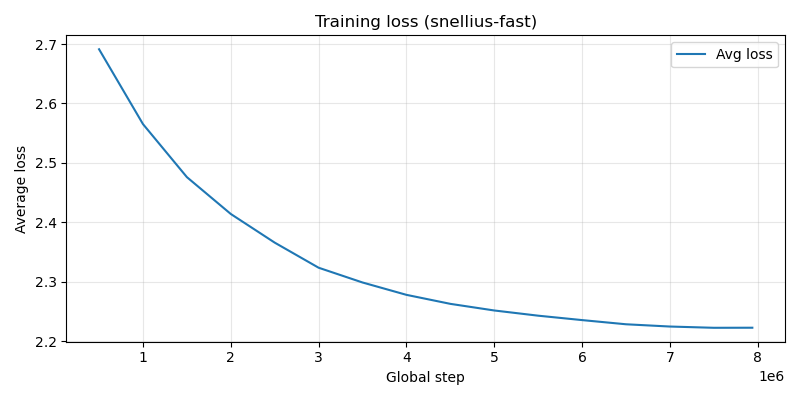

In [49]:
loss_npz = run_dir / f"loss_{run_name}.npz"
loss_png = run_dir / f"loss_{run_name}.png"

if loss_npz.exists():
    data = np.load(loss_npz)
    steps = data.get("steps")
    losses = data.get("losses")
    if losses is not None and len(losses) > 0:
        final_loss = float(losses[-1])
        print(f"Final recorded loss: {final_loss:.4f}")
    else:
        print("Loss file found but contains no entries.")
else:
    print(f"Loss data not found at {loss_npz}")
    steps = losses = None

# display the loss plot if it exists
if loss_png.exists(): display(Image(filename=str(loss_png)))


# Qualitative Similarity Checks

We can perform some simple similarity lookups to see if the model has learned meaningful relationships between word

In [50]:
def show_similar(query: str, top_k: int = 10):
    try:
        sims = model.get_most_similar(query, top_k=top_k)
    
    except Exception as exc:
        print(f"Error for '{query}': {exc}")
        return
    
    for word, score in sims:
        print(f"{word:>15}  {score:.4f}")

In [46]:
queries = ["cat", "dog", "computer", "king", "queen", "man", "woman", "italy"]

top_k = 10

for q in queries:
    print(f"\nTop {top_k} similar words to '{q}':")
    show_similar(q, top_k=top_k)


Top 10 similar words to 'cat':
    discography  0.9955
            cox  0.9950
         bowler  0.9949
        absalon  0.9945
         gerald  0.9945
           math  0.9944
       hercules  0.9942
      atanasoff  0.9941
       feminist  0.9940
          philo  0.9940

Top 10 similar words to 'dog':
           rank  0.9947
         speaks  0.9930
     supporting  0.9923
 correspondence  0.9921
        martyrs  0.9918
           belt  0.9911
          cable  0.9911
      extension  0.9910
       eugenics  0.9910
      notorious  0.9909

Top 10 similar words to 'computer':
      character  0.9732
          video  0.9718
           unit  0.9538
          model  0.9523
           game  0.9501
           text  0.9487
      alternate  0.9470
           code  0.9464
           star  0.9452
        science  0.9452

Top 10 similar words to 'king':
            son  0.9538
        brother  0.9454
       daughter  0.9430
        emperor  0.9400
        charles  0.9311
           paul  0.9295
  

# Analogy Checks

We can also test the model's ability to solve word analogies of the form "a is to b as c is to ?"

In [51]:
examples = [
    ("king", "queen", "man"),
    ("paris", "france", "rome"),
    ("man", "woman", "brother"),
    ("italy", "rome", "france"),
    ("computer", "computers", "phone"),
]

for a, b, c in examples:
    print(f"\n'{a}' : '{b}' :: '{c}' : ?")
    try:
        for word, score in model.analogy(a, b, c, top_k=5):
            print(f"{word:>15}  {score:.4f}")
    except Exception as exc:
        print(f"  error: {exc}")


'king' : 'queen' :: 'man' : ?
       position  1.0771
        success  1.0749
         making  1.0734
     successful  1.0707
       probably  1.0705

'paris' : 'france' :: 'rome' : ?
   independence  0.9844
          ended  0.9835
        britain  0.9817
         battle  0.9815
        elected  0.9801

'man' : 'woman' :: 'brother' : ?
        hungary  1.0332
         prince  1.0318
          paris  1.0302
          faber  1.0300
       daughter  1.0298

'italy' : 'rome' :: 'france' : ?
          birth  0.9599
         flight  0.9596
          month  0.9582
         signed  0.9577
          night  0.9576

'computer' : 'computers' :: 'phone' : ?
        pointed  1.1050
        suggest  1.1035
         engage  1.1015
      observers  1.1010
        unaware  1.0998
